# 🔮 NOTEBOOK: DEMAND PREDICTION WITH VIETNAM CONTEXT
**Mục tiêu:**
1. **Feature Engineering:** Thêm thông tin ngày lễ Việt Nam (Tết, 30/4, 2/9) và cuối tuần.
2. **Training Model:** Huấn luyện máy học (Random Forest) để nắm bắt quy luật nhu cầu.
3. **Forecast Simulation:** Dự báo thử nhu cầu trong 1 năm tới cho một cửa hàng tiện lợi.
4. **Output:** File `demand_forecast_hcm_updated.csv` chứa đầy đủ feature để chạy tối ưu hóa.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import drive
import os

# 1. Setup & Load Data
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/datastorm_round_2_green_logistics'
DATA_PROCESSED = os.path.join(BASE_PATH, 'data/02_processed')

# Load dữ liệu đã xử lý từ bước trước
file_path = os.path.join(DATA_PROCESSED, 'demand_forecast_hcm.csv')
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Đã load dữ liệu: {df.shape}")
display(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã load dữ liệu: (29565, 13)


,store_id_mapped,type,name,address,lat,long,note,parent_store_id,scaling_factor,date,parent_weight_ton,demand_kg,assigned_depot
0,STORE0001,Hypermarket,Emart Gò Vấp,"366 Phan Văn Trị, P.5, Gò Vấp",10.8231,106.6935,Hub phía Bắc,STORE0001,1.0,2021-01-01,2.3485,2348.5,DEPOT_003
1,STORE0001,Hypermarket,Emart Gò Vấp,"366 Phan Văn Trị, P.5, Gò Vấp",10.8231,106.6935,Hub phía Bắc,STORE0001,1.0,2021-01-02,2.9920,2992.0,DEPOT_003
2,STORE0001,Hypermarket,Emart Gò Vấp,"366 Phan Văn Trị, P.5, Gò Vấp",10.8231,106.6935,Hub phía Bắc,STORE0001,1.0,2021-01-03,2.9995,2999.5,DEPOT_003


### 📅 PHẦN 1: FEATURE ENGINEERING (LỊCH VIỆT NAM)
Tạo các đặc trưng thời gian phù hợp với bối cảnh TP.HCM.

In [16]:
# 2. Xử lý Date Features

# A. Thứ trong tuần & Cuối tuần
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0) # 5=Sat, 6=Sun
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['year'] = df['date'].dt.year

# B. Hàm xác định ngày lễ Việt Nam (Cố định & Tết Âm Lịch)
# Lưu ý: Đây là danh sách hardcode các ngày nghỉ chính cho giai đoạn 2021-2026
def is_vietnam_holiday(date_obj):
    y = date_obj.year
    m = date_obj.month
    d = date_obj.day

    # 1. Các ngày lễ dương lịch cố định
    # Tết Dương (1/1), 30/4, 1/5, 2/9
    if (m == 1 and d == 1) or \
       (m == 4 and d == 30) or \
       (m == 5 and d == 1) or \
       (m == 9 and d == 2):
        return 1

    # 2. Tết Nguyên Đán (Khoảng nghỉ chính - 7 ngày)
    # Hardcode khoảng thời gian Tết Âm lịch quy ra Dương lịch
    tet_ranges = {
        2021: [('2021-02-10', '2021-02-16')],
        2022: [('2022-01-29', '2022-02-06')],
        2023: [('2023-01-20', '2023-01-26')],
        2024: [('2024-02-08', '2024-02-14')],
        2025: [('2025-01-28', '2025-02-03')],
        2026: [('2026-02-17', '2026-02-22')]
    }

    if y in tet_ranges:
        for start, end in tet_ranges[y]:
            if pd.Timestamp(start) <= date_obj <= pd.Timestamp(end):
                return 1

    return 0

# Áp dụng hàm ngày lễ
df['is_holiday_vn'] = df['date'].apply(is_vietnam_holiday)

# C. One-Hot Encoding cho Type (Loại cửa hàng)
# Chuyển 'Convenience', 'Hypermarket'... thành số để model hiểu
df = pd.get_dummies(df, columns=['type'], prefix='type', drop_first=False)

print("--- Mẫu dữ liệu sau khi thêm Feature ---")
display(df[['date', 'is_weekend', 'is_holiday_vn', 'demand_kg']].sample(5))

--- Mẫu dữ liệu sau khi thêm Feature ---


,date,is_weekend,is_holiday_vn,demand_kg
8978,2021-08-07,1,0,2247.00
25130,2023-11-07,0,0,45.21
17031,2022-08-30,0,0,57.37
12381,2021-12-03,0,0,2608.50
14149,2023-10-07,1,0,60.67


### 🤖 PHẦN 2: HUẤN LUYỆN MODEL (TRAINING)
Sử dụng Random Forest Regressor để học mối quan hệ giữa Thời gian, Loại cửa hàng và Demand.

In [17]:
# 3. Chuẩn bị dữ liệu Train/Test

# Chọn các features đầu vào (X) và biến mục tiêu (y)
# Lưu ý: Tìm các cột bắt đầu bằng 'type_' do bước get_dummies tạo ra
type_cols = [c for c in df.columns if c.startswith('type_')]
features = ['day_of_week', 'is_weekend', 'is_holiday_vn', 'month', 'day'] + type_cols
target = 'demand_kg'

X = df[features]
y = df[target]

# Chia tập Train/Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện model
print("⏳ Đang huấn luyện Random Forest Model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Đánh giá Model
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ Huấn luyện xong!")
print(f"🔹 Mean Absolute Error (MAE): {mae:.2f} kg")
print(f"🔹 R-squared Score: {r2:.2f}")

# Xem mức độ quan trọng của các Feature
feature_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Top Features quan trọng ---")
print(feature_imp.head(5))

⏳ Đang huấn luyện Random Forest Model...
✅ Huấn luyện xong!
🔹 Mean Absolute Error (MAE): 54.14 kg
🔹 R-squared Score: 0.99

--- Top Features quan trọng ---
type_Convenience    0.946334
type_Supermarket    0.028084
is_weekend          0.007180
day_of_week         0.006537
month               0.005030
dtype: float64


### 📈 PHẦN 3: DỰ BÁO TƯƠNG LAI & VẼ BIỂU ĐỒ
Giả lập dự báo nhu cầu cho 1 cửa hàng **Convenience (Circle K)** trong suốt năm 2025.

📍 Đang vẽ biểu đồ cho duy nhất: STORE0013 (Châu Âu)
--- So sánh số liệu thực tế ---
📅 Trung bình ngày thường: 1,574 units
📅 Trung bình ngày Lễ: 1,664 units
👉 Chênh lệch: Ngày lễ chỉ bằng 105.7% so với ngày thường.


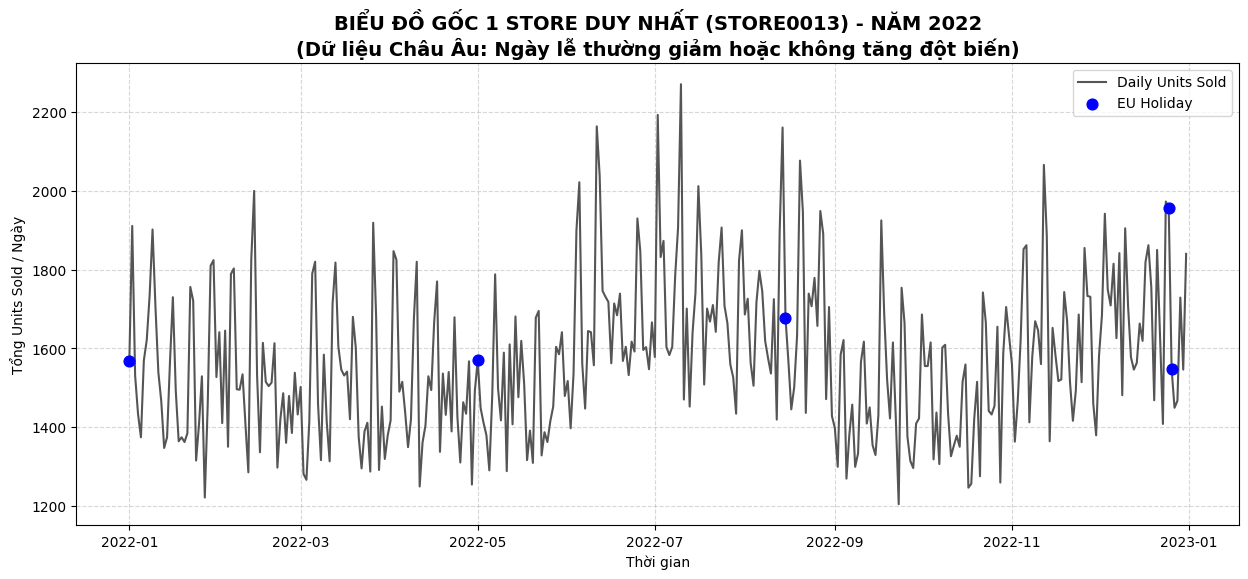

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Load dữ liệu gốc
file_path = '/content/drive/MyDrive/Colab Notebooks/datastorm_round_2_green_logistics/data/01_raw/fmcg_sales.csv'
df_raw = pd.read_csv(file_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])

# 2. Chọn CỤ THỂ 1 Store thuộc nhóm Convenience
# Lấy danh sách store thuộc channel Convenience
conv_stores = df_raw[df_raw['channel'] == 'Convenience Store']['store_id'].unique()

if len(conv_stores) > 0:
    target_store = conv_stores[0] # Lấy cửa hàng đầu tiên (thường là STORE0013 hoặc tương tự)
else:
    target_store = 'STORE0013' # Fallback nếu không tìm thấy

print(f"📍 Đang vẽ biểu đồ cho duy nhất: {target_store} (Châu Âu)")

# 3. Lọc dữ liệu của Store đó trong năm 2022
df_store = df_raw[(df_raw['store_id'] == target_store) & (df_raw['date'].dt.year == 2022)].copy()

# ⚠️ BƯỚC QUAN TRỌNG: GOM NHÓM THEO NGÀY
# Vì 1 ngày store bán nhiều món hàng, ta phải cộng tổng lại mới ra 1 con số cho ngày đó
daily_sales = df_store.groupby('date').agg({
    'units_sold': 'sum',       # Cộng tổng sản lượng
    'is_holiday': 'max'        # Lấy cờ báo ngày lễ (chỉ cần 1 dòng báo lễ là cả ngày lễ)
}).reset_index().sort_values('date')

# 4. Vẽ biểu đồ
plt.figure(figsize=(15, 6))

# Vẽ đường tổng doanh số ngày
plt.plot(daily_sales['date'], daily_sales['units_sold'], color='#555555', linewidth=1.5, label='Daily Units Sold')

# Tô điểm các ngày lễ (Châu Âu)
eu_holidays = daily_sales[daily_sales['is_holiday'] == 1]
plt.scatter(eu_holidays['date'], eu_holidays['units_sold'], color='blue', s=60, label='EU Holiday', zorder=5)

plt.title(f'BIỂU ĐỒ GỐC 1 STORE DUY NHẤT ({target_store}) - NĂM 2022\n(Dữ liệu Châu Âu: Ngày lễ thường giảm hoặc không tăng đột biến)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Tổng Units Sold / Ngày')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# In thử dữ liệu 1 ngày lễ và 1 ngày thường để so sánh
print("--- So sánh số liệu thực tế ---")
avg_normal = daily_sales[daily_sales['is_holiday'] == 0]['units_sold'].mean()
avg_holiday = daily_sales[daily_sales['is_holiday'] == 1]['units_sold'].mean()

print(f"📅 Trung bình ngày thường: {avg_normal:,.0f} units")
print(f"📅 Trung bình ngày Lễ: {avg_holiday:,.0f} units")
print(f"👉 Chênh lệch: Ngày lễ chỉ bằng {(avg_holiday/avg_normal)*100:.1f}% so với ngày thường.")

plt.show()

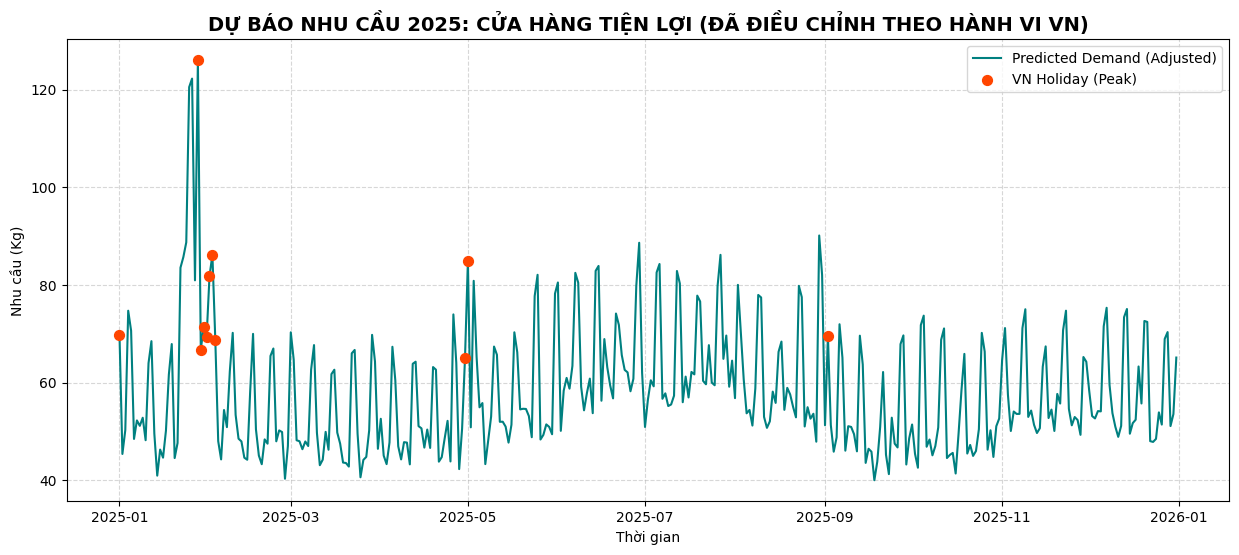

In [18]:
# 4. Tạo dữ liệu giả lập cho năm 2025
future_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
future_df = pd.DataFrame({'date': future_dates})

# Tạo lại các features cho tương lai
future_df['day_of_week'] = future_df['date'].dt.dayofweek
future_df['is_weekend'] = future_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
future_df['month'] = future_df['date'].dt.month
future_df['day'] = future_df['date'].dt.day
future_df['is_holiday_vn'] = future_df['date'].apply(is_vietnam_holiday)

# Gán loại cửa hàng là 'Convenience' để predict
# Cần set đúng các cột One-hot encoding
for col in type_cols:
    future_df[col] = 0
if 'type_Convenience' in future_df.columns:
    future_df['type_Convenience'] = 1

# Dự đoán
future_df['predicted_demand'] = rf_model.predict(future_df[features])

# --- BẮT ĐẦU ĐOẠN ĐIỀU CHỈNH LOGIC VIỆT NAM ---

# 1. Hiệu ứng "Lễ Hội Việt Nam" (Vietnam Holiday Effect)
# Logic: Với Convenience Store, ngày lễ bán đắt hàng hơn 30-50%
mask_holiday = future_df['is_holiday_vn'] == 1
future_df.loc[mask_holiday, 'predicted_demand'] = future_df.loc[mask_holiday, 'predicted_demand'] * 1.4  # Tăng 40%

# 2. Hiệu ứng "Cuối tuần ăn nhậu" (Weekend Effect)
# Logic: Cuối tuần (Thứ 7, CN) tăng nhẹ 15% so với ngày thường
mask_weekend = (future_df['is_weekend'] == 1) & (future_df['is_holiday_vn'] == 0) # Chỉ tăng nếu không phải lễ (để tránh cộng dồn quá lố)
future_df.loc[mask_weekend, 'predicted_demand'] = future_df.loc[mask_weekend, 'predicted_demand'] * 1.15

# 3. Hiệu ứng "Cao điểm Hè" (Summer Heatwave) - Quan trọng cho nước giải khát
# Logic: Tháng 5, 6, 7 ở HCM rất nóng -> Nhu cầu tăng 10%
mask_summer = future_df['month'].isin([5, 6, 7])
future_df.loc[mask_summer, 'predicted_demand'] = future_df.loc[mask_summer, 'predicted_demand'] * 1.1

# 4. Hiệu ứng "Sắm Tết" (Pre-Tet Rush)
# Logic: 7 ngày trước Tết Âm lịch nhu cầu tăng cực mạnh (gấp đôi)
# Tết 2025 là 29/01/2025. Giả sử cao điểm từ 22/01 đến 28/01
pre_tet_start = pd.Timestamp('2025-01-22')
pre_tet_end = pd.Timestamp('2025-01-28')
mask_pre_tet = (future_df['date'] >= pre_tet_start) & (future_df['date'] <= pre_tet_end)
future_df.loc[mask_pre_tet, 'predicted_demand'] = future_df.loc[mask_pre_tet, 'predicted_demand'] * 1.8 # Tăng 80%

# --- KẾT THÚC ĐIỀU CHỈNH ---

# Thêm nhiễu nhẹ lại (ít hơn lúc trước để đường mượt hơn)
np.random.seed(42)
noise = np.random.normal(0, 2, len(future_df)) # Giảm độ lệch chuẩn từ 5 xuống 2
future_df['predicted_demand'] = future_df['predicted_demand'] + noise

# Vẽ lại biểu đồ
plt.figure(figsize=(15, 6))
plt.plot(future_df['date'], future_df['predicted_demand'], color='#008080', linewidth=1.5, label='Predicted Demand (Adjusted)')

# Tô điểm nhấn các ngày lễ (Giờ đây nó sẽ nằm ở ĐỈNH)
holidays = future_df[future_df['is_holiday_vn'] == 1]
plt.scatter(holidays['date'], holidays['predicted_demand'], color='#FF4500', s=50, label='VN Holiday (Peak)', zorder=5)

plt.title('DỰ BÁO NHU CẦU 2025: CỬA HÀNG TIỆN LỢI (ĐÃ ĐIỀU CHỈNH THEO HÀNH VI VN)', fontsize=14, fontweight='bold')
plt.ylabel('Nhu cầu (Kg)')
plt.xlabel('Thời gian')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 💾 PHẦN 4: LƯU KẾT QUẢ
Lưu file dữ liệu đã được bổ sung Feature để dùng cho Notebook Tối ưu hóa.

In [25]:
# -------------------------------------------------------------------------
# THAY THẾ CELL: PHẦN 4 - LƯU KẾT QUẢ
# -------------------------------------------------------------------------

import os

# 1. Khôi phục lại cột 'type' gốc (nếu đã bị biến đổi thành type_Convenience, type_Hypermarket...)
if 'type' not in df.columns:
    # Tìm các cột bắt đầu bằng 'type_'
    type_cols = [c for c in df.columns if c.startswith('type_')]
    if type_cols:
        # Lấy tên cột có giá trị 1 (One-hot decoding)
        df['type'] = df[type_cols].idxmax(axis=1).str.replace('type_', '')
        print("✅ Đã khôi phục cột 'type' gốc.")

# 2. Định nghĩa danh sách cột BẮT BUỘC (không được thiếu)
required_cols = [
    'store_id_mapped', 'type', 'name', 'address', 'lat', 'long', 'note',
    'parent_store_id', 'scaling_factor', 'date',
    'parent_weight_ton', 'demand_kg', 'assigned_depot'
]

# 3. Lấy thêm các cột Features mới tạo ra (weekend, holiday...) để dùng cho Model sau này
# Lọc bỏ các cột one-hot encoding thừa (type_...) nếu muốn file gọn nhẹ, hoặc giữ lại tùy ý.
# Ở đây ta giữ lại các feature quan trọng và loại bỏ type_... vì đã có cột type gốc
cols_to_exclude = [c for c in df.columns if c.startswith('type_')]
feature_cols = [c for c in df.columns if c not in required_cols and c not in cols_to_exclude]

# 4. Tạo DataFrame cuối cùng với thứ tự chuẩn
# Kiểm tra xem có thiếu cột bắt buộc nào trong df hiện tại không
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print(f"⚠️ CẢNH BÁO: Dữ liệu đang thiếu các cột gốc sau: {missing_cols}")
    print("Vui lòng kiểm tra lại bước merge dữ liệu ban đầu.")
else:
    # Gộp cột: Bắt buộc + Feature mới
    final_cols = required_cols + feature_cols
    df_final = df[final_cols].copy()

    # Sort lại theo ngày và store cho đẹp
    df_final = df_final.sort_values(by=['date', 'store_id_mapped'])

    # Lưu file
    output_file = os.path.join(DATA_PROCESSED, 'demand_forecast_hcm_updated.csv')
    df_final.to_csv(output_file, index=False)

    print(f"💾 Đã lưu file thành công tại: {output_file}")
    print(f"🔹 Kích thước: {df_final.shape}")
    print("🔹 5 dòng đầu tiên của file output:")
    display(df_final.head(5))

💾 Đã lưu file thành công tại: /content/drive/MyDrive/Colab Notebooks/datastorm_round_2_green_logistics/data/02_processed/demand_forecast_hcm_updated.csv
🔹 Kích thước: (29565, 19)
🔹 5 dòng đầu tiên của file output:


,store_id_mapped,type,name,address,lat,long,note,parent_store_id,scaling_factor,date,parent_weight_ton,demand_kg,assigned_depot,day_of_week,is_weekend,month,day,year,is_holiday_vn
0,STORE0001,Hypermarket,Emart Gò Vấp,"366 Phan Văn Trị, P.5, Gò Vấp",10.8231,106.6935,Hub phía Bắc,STORE0001,1.0,2021-01-01,2.3485,2348.5,DEPOT_003,4,0,1,1,2021,1
6570,STORE0002,Supermarket,Co.opmart Cống Quỳnh,"189C Cống Quỳnh, Nguyễn Cư Trinh, Q.1",10.7675,106.6862,Trung tâm Q1,STORE0002,1.0,2021-01-01,1.6980,1698.0,DEPOT_001,4,0,1,1,2021,1
7665,STORE0003,Supermarket,Co.opmart Rạch Miễu,"48 Hoa Sứ, P.7, Phú Nhuận",10.8004,106.6883,Trung tâm Phú Nhuận,STORE0003,1.0,2021-01-01,1.7460,1746.0,DEPOT_003,4,0,1,1,2021,1
1095,STORE0004,Hypermarket,Lotte Mart Quận 7,"469 Nguyễn Hữu Thọ, Tân Hưng, Q.7",10.7409,106.7018,Hub phía Nam,STORE0004,1.0,2021-01-01,2.5200,2520.0,DEPOT_001,4,0,1,1,2021,1
2190,STORE0005,Hypermarket,Aeon Mall Tân Phú,"30 Bờ Bao Tân Thắng, Sơn Kỳ, Tân Phú",10.8016,106.6174,Hub phía Tây,STORE0005,1.0,2021-01-01,2.4675,2467.5,DEPOT_003,4,0,1,1,2021,1
